In [6]:
import sys
sys.path.append('../../Python_scripts')
sys.path.append('../FRB_cosmo/FRB_cosmo/interpolation')

## Import packages
from config import *
from support import *
from cosmo_support import *

import pickle
import os
from datetime import datetime

import emcee
from multiprocess import Pool, cpu_count

In [7]:
# initial parameters
Hubble0 = 70
e_mu0 = 150
sigma_host0 = 0.5

# MCMC parameters
N_WALKERS = 16
HEATING = 10
N_STEPS = 800

# checkpoint
RESUME = False
CKP_INTERVAL = 50
SAVE_FILE = './DM_ext_checkpoint/simulation_data.pkl'
MCMC_FILE = './DM_ext_checkpoint/mcmc_checkpoint.pkl'

DATA_PATH = '../FRB_cosmo/interpolation/095_C0mean.npz'
interpolations = np.load(f'../Realistic_sources/quantile_linear_interpolations.npz')

N_EVENTS = 20
REDSHIFT_METHOD = 'rates'  # choose from 'rates', 'uniform', 'gaussian', 'lognormal' and 'powerlaw'

########################################
### Load standard parameters for pdf ###
########################################

S=0.133
EXP_MU=182.937
SIGMA_HOST=0.605
HOF=2.813

In [8]:
print(HUBBLE* OMEGA_BARYONS*0.84)

2.7831805679999997


In [9]:
###################################
### Load interpolations for pdf ###
###################################

def _load_and_create_interpolators():
    load_arrays = np.load(DATA_PATH)
    Sigmas = load_arrays['a']
    Errors = load_arrays['d']
    C0s = load_arrays['c'] 
    As = load_arrays['b']
    
    sigma_error_inter = interpolate.interp1d(Errors, Sigmas, kind=1, bounds_error=False,fill_value='extrapolate')
    C0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1, bounds_error=False,fill_value='extrapolate')
    A_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1, bounds_error=False,fill_value='extrapolate')
    
    return Sigmas, Errors, C0s, As, sigma_error_inter, C0_sigma_inter, A_sigma_inter

Sigmas, Errors, C0s, As, sigma_error_inter, C0_sigma_inter, A_sigma_inter = _load_and_create_interpolators()

z_array=np.linspace(0.2, 4.0, 1000)

# p_selection = redshift_distribution(z_array=z_array, H0=HUBBLE, Omega_m=OMEGA_MATTER, w, method=REDSHIFT_METHOD)
# p_selection = normalise(p_selection, z_array)

def initialize_globals():
    """Initialize global variables for worker processes"""
    global sigma_error_inter, C0_sigma_inter, A_sigma_inter
    global z_array
    
    if sigma_error_inter is None:
        Sigmas, Errors, C0s, As, sigma_error_inter, C0_sigma_inter, A_sigma_inter = _load_and_create_interpolators()
        z_array = np.linspace(0.2, 4.0, 1000)

In [16]:
N=1000

DM_obs = np.zeros(N)
sigma_obs = np.zeros(N)
DM_obs_fast = np.zeros(N)
sigma_obs_fast = np.zeros(N)

z_val=1.0

for idx in range(N):

    DM_obs[idx], sigma_obs[idx] = \
        DM_ext_sampling(z=z_val, 
                        S=S, HOF=HOF, SIGMA_HOST=SIGMA_HOST, EXP_MU=EXP_MU,
                        sigma_error_inter=sigma_error_inter,
                        C0_sigma_inter=C0_sigma_inter,
                        A_sigma_inter=A_sigma_inter,
                        Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1, int_N=2000
                        )
        
    DM_obs_fast[idx], sigma_obs_fast[idx] = \
        DM_ext_sampling_fast(z=z_val, 
                        S=S, HOF=HOF, SIGMA_HOST=SIGMA_HOST, EXP_MU=EXP_MU,
                        sigma_error_inter=sigma_error_inter,
                        C0_sigma_inter=C0_sigma_inter,
                        A_sigma_inter=A_sigma_inter,
                        Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1, int_N=2000
                        )

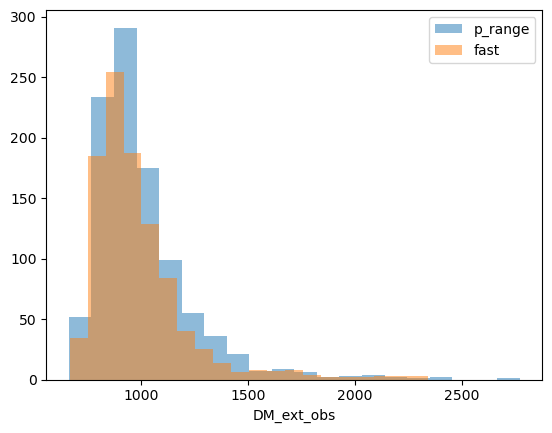

In [17]:
plt.hist(DM_obs, bins=20, label='p_range', alpha=0.5)
plt.hist(DM_obs_fast, bins=20, label='fast', alpha=0.5)
plt.xlabel('DM_ext_obs')
plt.legend()

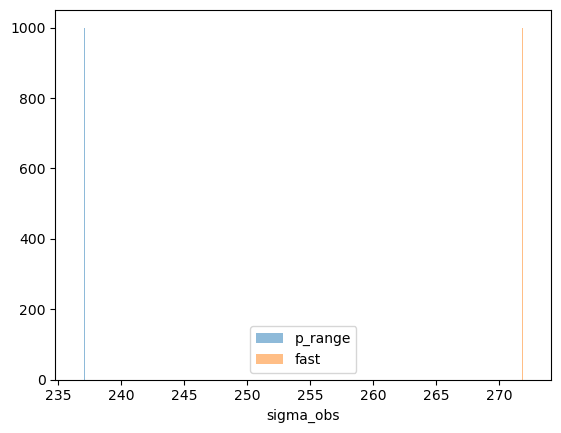

In [18]:
plt.hist(sigma_obs, bins=20, label='p_range', alpha=0.5)
plt.hist(sigma_obs_fast, bins=20, label='fast', alpha=0.5)
plt.xlabel('sigma_obs')
plt.legend()